# K-means Clustering Exercise
[ref](https://www.kaggle.com/code/heeraldedhia/kmeans-clustering-for-customer-data)


## About the dataset

This input file contains the basic information (ID, age, gender, income, spending score) about the customers of a mall. Spending Score is something you assign to the customer based on your defined parameters like customer behavior and purchasing data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly as py
import plotly.graph_objs as go

from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('data/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**ตรวจสอบหาค่าว่าง NULL**

In [5]:
# Your code here
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

**EX: Plot histrogram โดยใช้ `plt.subplots()` สำหรับข้อมูล Age , Annual Income (k$) , Spending Score (1-100)**

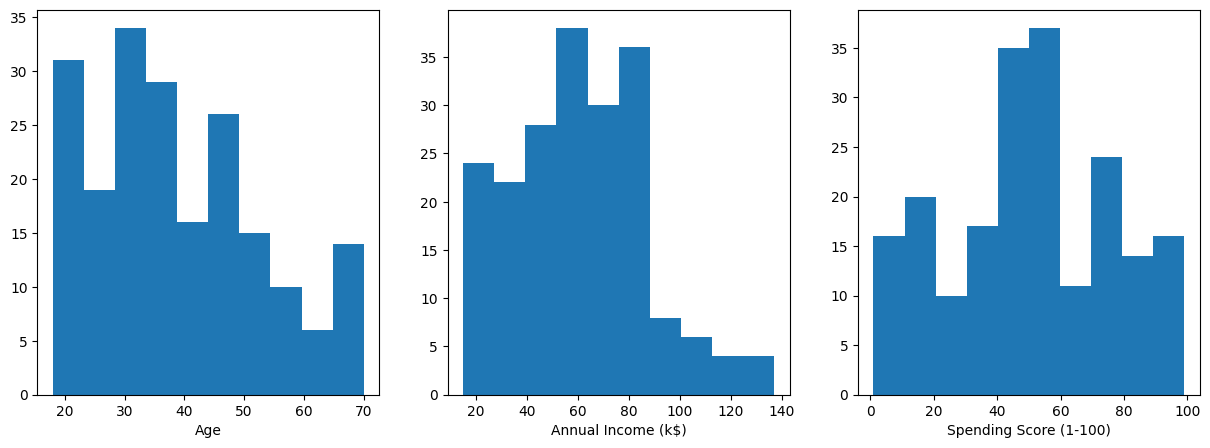

In [6]:
# Your code here
fig,axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
axs[0].hist(df['Age'])
axs[0].set_xlabel('Age')
axs[1].hist(df['Annual Income (k$)'])
axs[1].set_xlabel('Annual Income (k$)')
axs[2].hist(df['Spending Score (1-100)'])
axs[2].set_xlabel('Spending Score (1-100)')
plt.show()

**EX: Plot scatter plot ระหว่าง Age v/s Spending Score (1-100)**

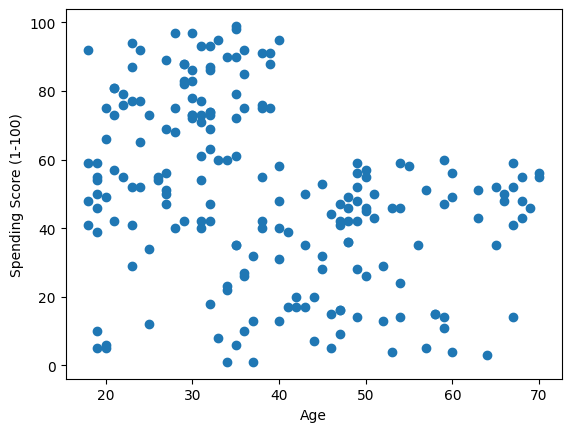

In [7]:
# Your code here
plt.scatter(df['Age'], df['Spending Score (1-100)'])
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

**EX: Plot scatter plot ระหว่าง Age v/s Annual Income (k$)**

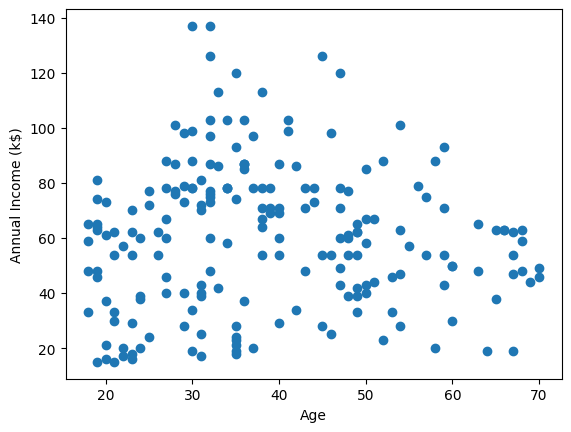

In [8]:
# Your code here
plt.scatter(df['Age'], df['Annual Income (k$)'])
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()

**EX: Plot scatter plot ระหว่าง Annual Income (k$) v/s Spending Score (1-100)**

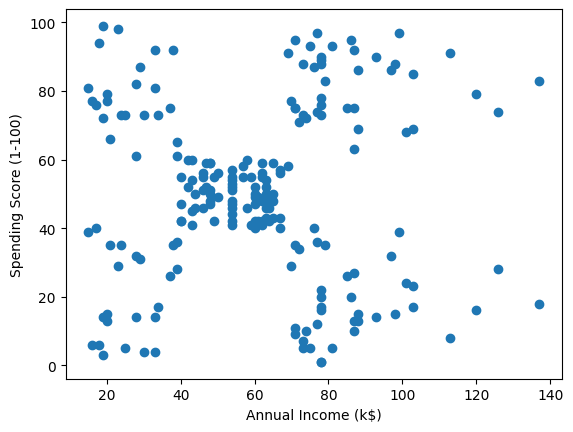

In [9]:
# Your code here
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

**Drop column `Gender` และ `CustomerId`**

In [10]:
df2 = df.drop(columns=["Gender", "CustomerID"])

**EX: Scale ข้อมูลใน df2 โดยใช้ StandardScaler**

In [11]:
# Your code here
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df2)
# statistics of scaled data
data_scaled = pd.DataFrame(data_scaled, columns=df2.columns)


In [12]:
data_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


### 3D Clustering Age , Annual Income and Spending Score

**EX: ทำ K-means โดยกำหนด K = 1 ถึง 10 และวาดกราฟ plot ค่า inertia เพื่อหา K ที่ดีที่สุด (Elbow Method)**

In [13]:
# Do K-means
# Hint: Use algorithm.inertia_
# defining the kmeans function with initialization as k-means++
kmeans = KMeans(n_clusters=10, init='k-means++', n_init='auto')

# fitting the k means algorithm on scaled data
kmeans.fit(data_scaled)
kmeans.inertia_
kmeans

KMeans(n_clusters=10)

Text(0, 0.5, 'Inertia')

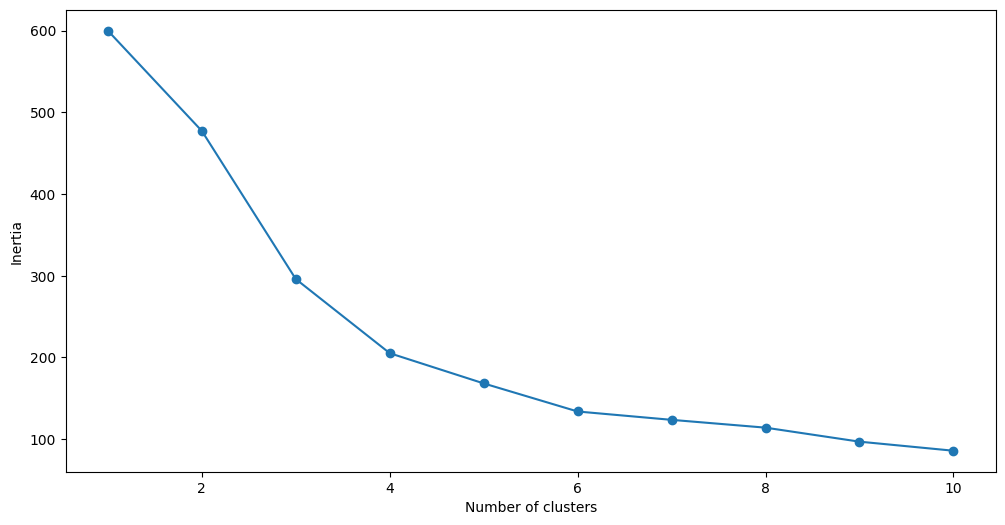

In [14]:
# fitting multiple k-means algorithms and storing the values in an empty list
SSE = []
for cluster in range(1,11):
    kmeans = KMeans(n_clusters = cluster, init='k-means++', n_init='auto')
    kmeans.fit(data_scaled)
    SSE.append(kmeans.inertia_)

# converting the results into a dataframe and plotting them
frame = pd.DataFrame({'Cluster':range(1,11), 'SSE':SSE})
plt.figure(figsize=(12,6))
plt.plot(frame['Cluster'], frame['SSE'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [15]:

frame = pd.DataFrame({'Cluster':range(1,11),})
frame


,Cluster
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


**EX: ทำ K-means อีกครั้งโดยใช้ K ที่ดีที่สุด**

In [16]:
# Your code here
# k means using 5 clusters and k-means++ initialization
kmeans = KMeans(n_clusters = 5, init='k-means++', n_init='auto')
kmeans.fit(data_scaled)
y_pred = kmeans.predict(data_scaled)

In [17]:
s = pd.Series(y_pred)

In [18]:
s.value_counts()

2    58
4    48
1    39
0    33
3    22
Name: count, dtype: int64

In [19]:
df['cluster'] = y_pred
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


**Plot graph 3D**

In [20]:
import plotly as py
import plotly.graph_objs as go

trace1 = go.Scatter3d(
    x= df['Age'],
    y= df['Spending Score (1-100)'],
    z= df['Annual Income (k$)'],
    mode='markers',
     marker=dict(
        color = df['cluster'],
        size= 10,
        line=dict(
            color= df['cluster'],
            width= 12
        ),
        opacity=0.8
     )
)
data = [trace1]
layout = go.Layout(
    title= 'Clusters wrt Age, Income and Spending Scores',
    scene = dict(
            xaxis = dict(title  = 'Age'),
            yaxis = dict(title  = 'Spending Score'),
            zaxis = dict(title  = 'Annual Income')
        )
)
fig = go.Figure(data=data, layout=layout)
py.offline.iplot(fig)

**EX: ลองทำ Hierarchical Clustering ดูสิ**

In [21]:
# Your code here




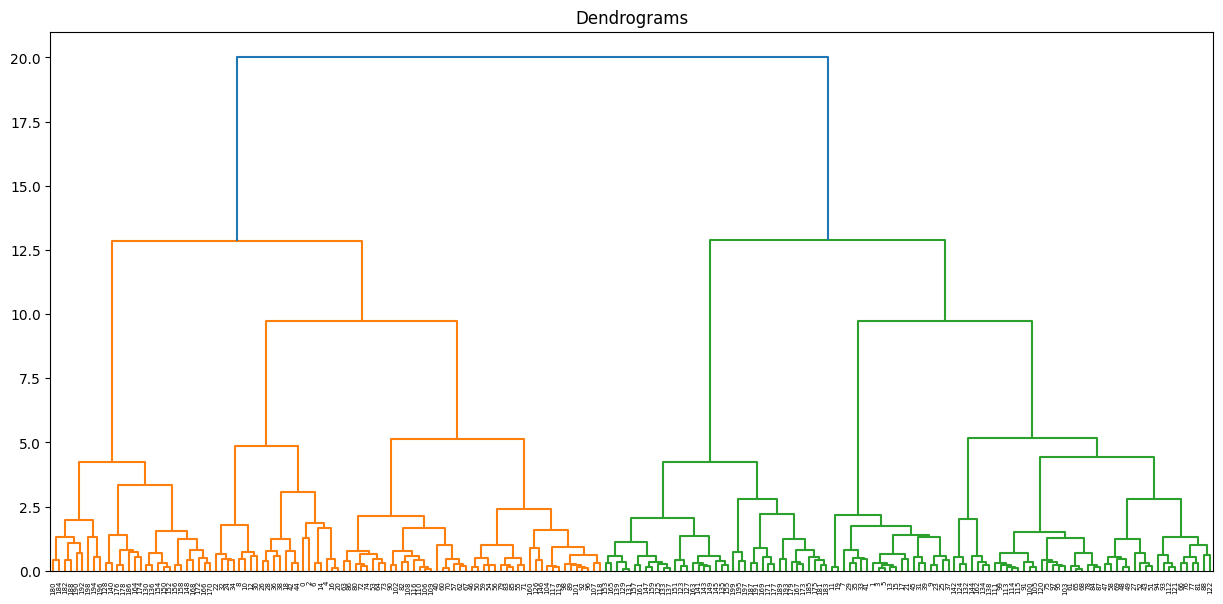

In [22]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(15, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))

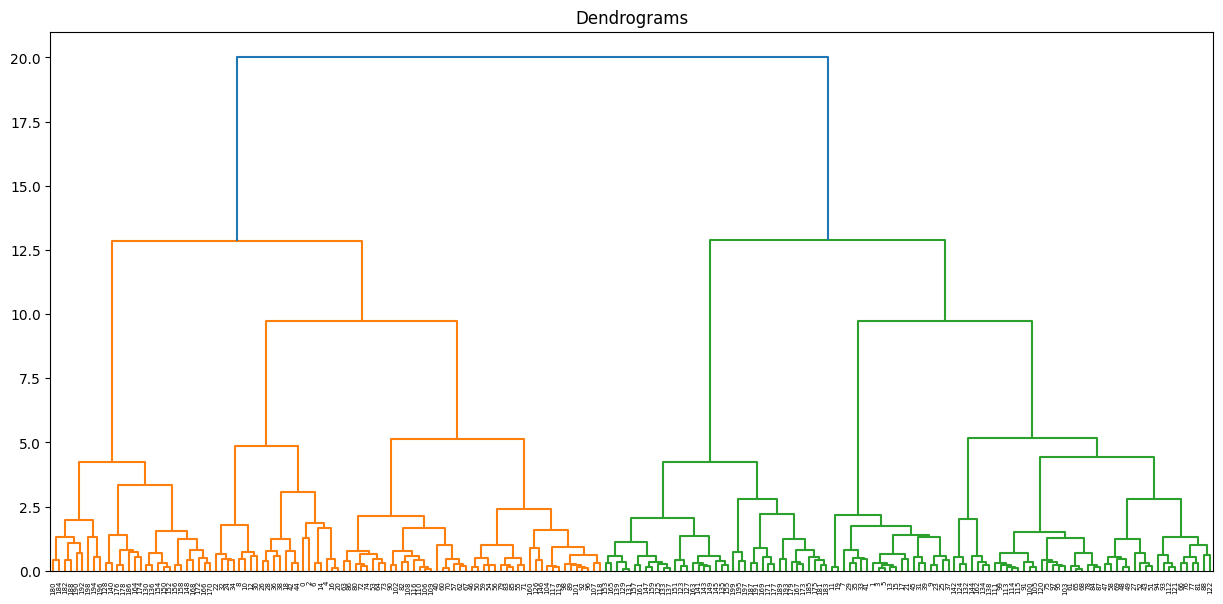

In [23]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(15, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))

In [24]:
# Fit AgglomerativeClustering


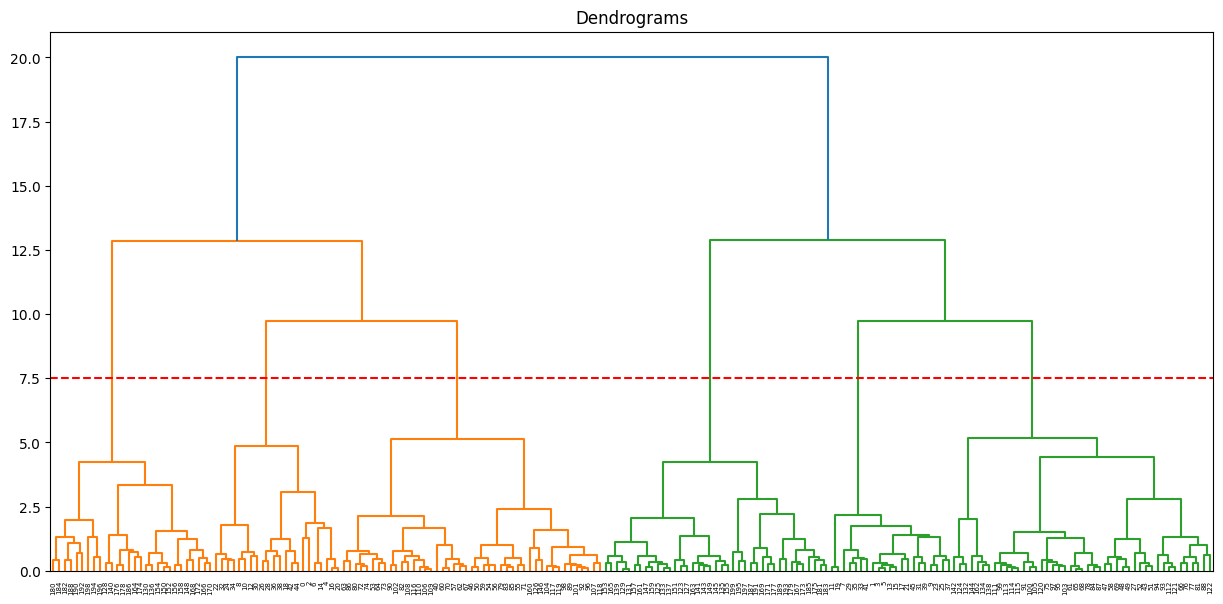

In [25]:
plt.figure(figsize=(15, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))
plt.axhline(y=7.5, color='r', linestyle='--')

In [26]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=6, metric='euclidean', linkage='ward')
cluster_results = cluster.fit_predict(data_scaled)

In [27]:
# Plot 3D graph


In [28]:
df2['cluster'] = cluster_results

In [29]:
df2['cluster'].value_counts()

cluster
0    45
1    45
2    39
3    28
4    22
5    21
Name: count, dtype: int64

In [30]:
df2['cluster'] = cluster_results

In [31]:
import plotly as py
import plotly.graph_objs as go

trace1 = go.Scatter3d(
    x= df['Age'],
    y= df['Spending Score (1-100)'],
    z= df['Annual Income (k$)'],
    mode='markers',
     marker=dict(
        color = df['cluster'],
        size= 10,
        line=dict(
            color= df['cluster'],
            width= 12
        ),
        opacity=0.8
     )
)
data = [trace1]
layout = go.Layout(
    title= 'Clusters wrt Age, Income and Spending Scores',
    scene = dict(
            xaxis = dict(title  = 'Age'),
            yaxis = dict(title  = 'Spending Score'),
            zaxis = dict(title  = 'Annual Income')
        )
)
fig = go.Figure(data=data, layout=layout)
py.offline.iplot(fig)

**EX: ลองทำ clustering ด้วย DBSCAN**

In [32]:
# Your code here


Number of clusters: 7
Silhouette Coefficient: -0.080


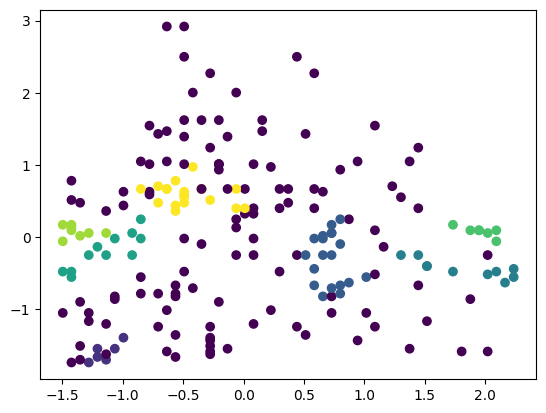

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

from sklearn.cluster import DBSCAN




X = data_scaled.values
db = DBSCAN(eps=0.3, min_samples=4)

y_pred = db.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=y_pred)
print('Number of clusters: {}'.format(len(set(y_pred[np.where(y_pred != -1)]))))
print("Silhouette Coefficient: %0.3f"% metrics.silhouette_score(X, db.labels_))
# Silhouette Coefficient or silhouette score is a metric used to calculate the goodness of a clustering technique. Its value ranges from -1 to 1.
# 1: Means clusters are well apart from each other and clearly distinguished.
# 0: Means clusters are indifferent, or we can say that the distance between clusters is not significant.
# -1: Means clusters are assigned in the wrong way.

In [34]:
# Plot 3D graph
